<a href="https://colab.research.google.com/github/zain4cs/DecodeLab_Intern/blob/main/Project2_Fraud_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline



In [ ]:
df = pd.read_csv("/content/fraudTest.csv")
df.head()

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,0,2020-06-21 12:14:25,2.291164e+15,fraud_Kirlin and Sons,personal_care,2.86,Jeff,Elliott,M,351 Darlene Green,...,33.9659,-80.9355,333497.0,Mechanical engineer,1968-03-19,2da90c7d74bd46a0caf3777415b3ebd3,1.371817e+09,33.986391,-81.200714,0.0
1,1,2020-06-21 12:14:33,3.573030e+15,fraud_Sporer-Keebler,personal_care,29.84,Joanne,Williams,F,3638 Marsh Union,...,40.3207,-110.4360,302.0,"Sales professional, IT",1990-01-17,324cc204407e99f51b0d6ca0055005e7,1.371817e+09,39.450498,-109.960431,0.0
2,2,2020-06-21 12:14:53,3.598215e+15,"fraud_Swaniawski, Nitzsche and Welch",health_fitness,41.28,Ashley,Lopez,F,9333 Valentine Point,...,40.6729,-73.5365,34496.0,"Librarian, public",1970-10-21,c81755dbbbea9d5c77f094348a7579be,1.371817e+09,40.495810,-74.196111,0.0
3,3,2020-06-21 12:15:15,3.591920e+15,fraud_Haley Group,misc_pos,60.05,Brian,Williams,M,32941 Krystal Mill Apt. 552,...,28.5697,-80.8191,54767.0,Set designer,1987-07-25,2159175b9efe66dc301f149d3d5abf8c,1.371817e+09,28.812398,-80.883061,0.0
4,4,2020-06-21 12:15:17,3.526826e+15,fraud_Johnston-Casper,travel,3.19,Nathan,Massey,M,5783 Evan Roads Apt. 465,...,44.2529,-85.0170,1126.0,Furniture designer,1955-07-06,57ff021bd3f328f8738bb535c302a31b,1.371817e+09,44.959148,-85.884734,0.0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 128200 entries, 0 to 128199
Data columns (total 23 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   Unnamed: 0             128200 non-null  int64  
 1   trans_date_trans_time  128200 non-null  object 
 2   cc_num                 128199 non-null  float64
 3   merchant               128199 non-null  object 
 4   category               128199 non-null  object 
 5   amt                    128199 non-null  float64
 6   first                  128199 non-null  object 
 7   last                   128199 non-null  object 
 8   gender                 128199 non-null  object 
 9   street                 128199 non-null  object 
 10  city                   128199 non-null  object 
 11  state                  128199 non-null  object 
 12  zip                    128199 non-null  float64
 13  lat                    128199 non-null  float64
 14  long                   128199 non-nu

In [ ]:
df.isnull().sum().sort_values(ascending=False)

,0
cc_num,1
category,1
merchant,1
amt,1
first,1
gender,1
last,1
city_pop,1
job,1
street,1


_____________________

**EDA (Exploratory Data Analysis)**

In [ ]:
fraud_count = df["is_fraud"].value_counts()
print("Legitimate transactions:", fraud_count[0])
print("Fraud transactions:", fraud_count[1])
print("Fraud percentage:", round(fraud_count[1]/len(df)*100, 2), "%")

Legitimate transactions: 127685
Fraud transactions: 514
Fraud percentage: 0.4 %


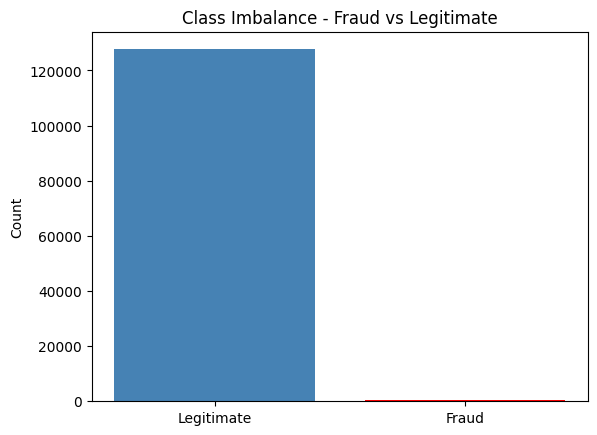

In [ ]:
# Graph
plt.bar(["Legitimate", "Fraud"], fraud_count.values, color=["steelblue", "red"])
plt.title("Class Imbalance - Fraud vs Legitimate")
plt.ylabel("Count")
plt.savefig("graph1_imbalance.png", dpi=150)
plt.show()

In [ ]:
# CELL 7 - Duplicates
duplicates = df.duplicated().sum()
print("Duplicate rows:", duplicates)

Duplicate rows: 0


In [ ]:
# CELL 8 - Transaction Amount Stats
print("Amount column stats:")
print(df["amt"].describe())

Amount column stats:
count    128199.000000
mean         69.205013
std         152.097926
min           1.000000
25%           9.610000
50%          47.250000
75%          82.860000
max       13149.150000
Name: amt, dtype: float64


______________________

**Data Cleaning**

In [ ]:
df = df.dropna()
print("Shape after dropping missing rows:", df.shape)

Shape after dropping missing rows: (128199, 23)


In [ ]:
useless_cols = ["Unnamed: 0", "first", "last", "street",
                "cc_num", "trans_num", "trans_date_trans_time",
                "dob", "zip", "merchant"]

In [ ]:
df = df.drop(columns=useless_cols)
print("New shape:", df.shape)
print("Remaing columns:", df.columns.tolist())

New shape: (128199, 13)
Remaing columns: ['category', 'amt', 'gender', 'city', 'state', 'lat', 'long', 'city_pop', 'job', 'unix_time', 'merch_lat', 'merch_long', 'is_fraud']


Outliers

In [ ]:
for col in ["amt", "city_pop"]:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    print(f"{col}: {len(outliers)} outliers detected")

amt: 6405 outliers detected
city_pop: 23997 outliers detected


In [ ]:
for col in ["amt", "city_pop"]:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df[col] = np.clip(df[col], lower, upper)

    print("Outliers neutralize!")

Outliers neutralize!
Outliers neutralize!


In [ ]:
# Categorical Columns Convert into Numbers

df["gender"] = df["gender"].map({"M": 1, "F": 0})

df = pd.get_dummies(df, columns=["category", "state", "city", "job"], drop_first=True)

print("Encoding complete!")
print("New shape:", df.shape)

Encoding complete!
New shape: (128199, 1384)


___________________

**Train/Test Split**

In [ ]:
X = df.drop(columns=["is_fraud"])  # Features
y = df["is_fraud"]                  # Target (0=legitimate, 1=fraud)

print("Features shape:", X.shape)
print("Target shape:", y.shape)
print("Fraud in target:", y.sum())

Features shape: (128199, 1383)
Target shape: (128199,)
Fraud in target: 514.0


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training set size:", X_train.shape[0])
print("Testing set size:", X_test.shape[0])
print("Fraud in training:", y_train.sum())
print("Fraud in testing:", y_test.sum())

Training set size: 102559
Testing set size: 25640
Fraud in training: 411.0
Fraud in testing: 103.0


________________

**Model Training**

**Model 1:** Logistic Regression (Simple, Linear)


**Model 2:** Random Forest (Powerful, Tree-based)

In [ ]:
lr_pipeline = Pipeline([
    ("smote", SMOTE(random_state=42)),
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000, random_state=42))
])

print("Training Logistic Regression.")
lr_pipeline.fit(X_train, y_train)
print("Logistic Regression training complete!")

Training Logistic Regression.
Logistic Regression training complete!


In [ ]:
#  Model 2: Random Forest + SMOTE Pipeline

rf_pipeline = Pipeline([
    ("smote", SMOTE(random_state=42)),
    ("model", RandomForestClassifier(n_estimators=100, random_state=42))
])

print("Training Random Forest.")
rf_pipeline.fit(X_train, y_train)
print("Random Forest training complete!")

Training Random Forest.
Random Forest training complete!


**Model Evaluation**

In [ ]:
# Logistic Regression Results


lr_pred = lr_pipeline.predict(X_test)
lr_auc = roc_auc_score(y_test, lr_pipeline.predict_proba(X_test)[:,1])

print("=== Logistic Regression Results ===")
print(classification_report(y_test, lr_pred, target_names=["Legitimate", "Fraud"]))
print("ROC-AUC Score:", round(lr_auc, 4))

=== Logistic Regression Results ===
              precision    recall  f1-score   support

  Legitimate       1.00      0.99      1.00     25537
       Fraud       0.27      0.66      0.38       103

    accuracy                           0.99     25640
   macro avg       0.63      0.83      0.69     25640
weighted avg       1.00      0.99      0.99     25640

ROC-AUC Score: 0.9889


In [ ]:
# Random Forest Results


rf_pred = rf_pipeline.predict(X_test)
rf_auc = roc_auc_score(y_test, rf_pipeline.predict_proba(X_test)[:,1])

print("=== Random Forest Results ===")
print(classification_report(y_test, rf_pred, target_names=["Legitimate", "Fraud"]))
print("ROC-AUC Score:", round(rf_auc, 4))

=== Random Forest Results ===
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     25537
       Fraud       0.89      0.66      0.76       103

    accuracy                           1.00     25640
   macro avg       0.95      0.83      0.88     25640
weighted avg       1.00      1.00      1.00     25640

ROC-AUC Score: 0.9973


_____________

**Compair Both Models**

In [ ]:
print("=" * 40)
print("MODEL COMPARISON")
print("=" * 40)
print(f"Logistic Regression ROC-AUC: {round(lr_auc, 4)}")
print(f"Random Forest ROC-AUC:       {round(rf_auc, 4)}")
print()
if rf_auc > lr_auc:
    print("Winner: Random Forest!")
else:
    print("Winner: Logistic Regression!")

MODEL COMPARISON
Logistic Regression ROC-AUC: 0.9889
Random Forest ROC-AUC:       0.9973

Winner: Random Forest!


____________________

**Graph**

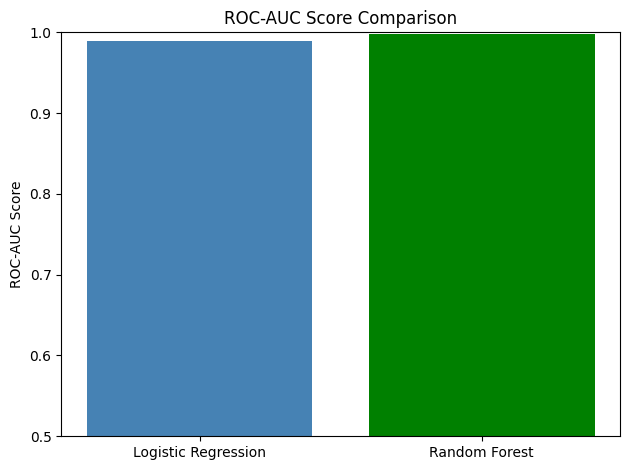

In [ ]:
models = ["Logistic Regression", "Random Forest"]
auc_scores = [lr_auc, rf_auc]

plt.bar(models, auc_scores, color=["steelblue", "green"])
plt.title("ROC-AUC Score Comparison")
plt.ylabel("ROC-AUC Score")
plt.ylim(0.5, 1.0)
plt.tight_layout()
plt.savefig("graph4_comparison.png", dpi=150)
plt.show()